#  Project Stage III — Machine Learning Models

## In this stage, you will test your hypotheses statistically and explore how machine learning models can capture relationships in your cleaned dataset. This task builds the bridge between statistics and predictive modeling.

### Task 1- Hypothesis Verification (30 points)

Revisit all the Hypothsis questions proposed in Stage II.  

a. Write the hypotheses explicitly: 

Does a longer accident duration lead to a higher accident severity? For this question we will look at Start_Time, End_Time, and Severity.

    Null (H₀): There is no relationship between accident duration and accident severity
    Alternative (H₁): There exists a relationship between accident duration and accident severity

Are accidents near traffic signals, juntions, railways or crossings more severe than those occuring else where? For this one we will compare against Severity, Traffic_Signal, Junction, Crossing, and Railway.

     Null (H₀): There is no relationship between accident severity and traffic signals, junctions, or crossings.
    Alternative (H₁): There exists a relationship between accident severity and traffic signals, junctions, or crossings.

Does weather effect the severity of an accident? Here we will look at temperature, percipitation, and severity.
    
    Null (H₀): There is no relationship between accident severity and temperature, percipitation, or visibility.
    Alternative (H₁): There exists a relationship between accident severity and temperature, percipitation, or visibility.

b. Then choose and justify an approporiate test:
    
    t-test / ANOVA – compare means across groups.

    Chi-square test – association between two categorical variables.

    Correlation test (Pearson/Spearman) – relationship between continuous or ordinal variables.

    Regression coefficient test – check if a variable significantly predicts another.

#### The Regression coefficient test would be most helpful for our hypotheses due to the fact that each one is looking at variable(s) in an attempt to predict the severity level of car accidents.

c. Report the test statistic, p-value and compare them with significance level ($\alpha = 0.05$), interpret your results clearly: Reject $H_0$ or fail to reject $H_0$ and explain what it means in the context of your dataset.

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np
from sklearn.model_selection import train_test_split

data = pd.read_csv("../data/newdata.csv")
# change severity values to either low(0) or high(1)
data['Severity'] = data['Severity'].replace({1: 0, 2: 0, 3: 1, 4: 1})

# changing names of cols due to errors
data.rename(columns = {"Precipitation(in)": "rain", "Temperature(F)": "temp", "Visibility(mi)": "vis"}, inplace = True)

print(data.head())

# Get accident duration in minutes
data['Start_Time'] = pd.to_datetime(data['Start_Time'])
data['End_Time'] = pd.to_datetime(data['End_Time'])

data['Duration'] = (data['End_Time'] - data['Start_Time']) / pd.Timedelta(minutes=1)

model = smf.ols('Severity ~ temp + rain + vis', data=data).fit()
print('Weather variable statistics:')
# Print the summary, which includes p-values
print(model.summary())
# Access p-values directly
print(f"P-values for coefficients: {model.pvalues}")
print(f"test statistic: {model.tvalues}")

   Severity           Start_Time             End_Time Sunrise_Sunset  temp  \
0         1  2016-02-08 05:46:00  2016-02-08 11:00:00          Night  36.9   
1         0  2016-02-08 06:07:59  2016-02-08 06:37:59          Night  37.9   
2         0  2016-02-08 06:49:27  2016-02-08 07:19:27          Night  36.0   
3         1  2016-02-08 07:23:34  2016-02-08 07:53:34          Night  35.1   
4         0  2016-02-08 07:39:07  2016-02-08 08:09:07            Day  36.0   

   rain   vis Weather_Condition  Traffic_Signal  Junction  Crossing  Railway  \
0  0.02  10.0        Light Rain           False     False     False    False   
1  0.00  10.0        Light Rain           False     False     False    False   
2  0.00  10.0          Overcast            True     False     False    False   
3  0.00   9.0     Mostly Cloudy           False     False     False    False   
4  0.00   6.0     Mostly Cloudy            True     False     False    False   

  State          City  
0    OH        Dayton  
1 

#### Based on the p values listed above we can see that the temperature and percipitation variables are less than 0.05 and therefore are correlated with the severity. We fail to reject the null hypothesis for temperature and rain but we reject the null hypothesis for visibility. The test statistics point towards a positive correlation between the weather variables and the target variable, severity.

In [75]:
model = smf.ols('Severity ~ Traffic_Signal + Junction + Crossing', data=data).fit()
print('Traffic variable statistics:')
# Print the summary, which includes p-values
print(model.summary())
# Access p-values directly
print(f"P-values for coefficients: {model.pvalues}")
print(f"test statistic: {model.tvalues}")

Traffic variable statistics:
                            OLS Regression Results                            
Dep. Variable:               Severity   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     1776.
Date:                Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:01:42   Log-Likelihood:                -69456.
No. Observations:              100000   AIC:                         1.389e+05
Df Residuals:                   99996   BIC:                         1.390e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

#### Based on the data listed above we can see that all the traffic variables have very small p values and therefore we fail to reject the null hypothesis for all of them. For accidents that involved a traffic signal or crossing, the statistics determined a negative correlation whereas where there is a junction there is a positive correlation.

In [77]:
model = smf.ols('Severity ~ Duration', data=data).fit()
print('Duration variable statistics:')
# Print the summary, which includes p-values
print(model.summary())
# Access p-values directly
print(f"P-values for coefficients: {model.pvalues}")
print(f"test statistic: {model.tvalues}")

Duration variable statistics:
                            OLS Regression Results                            
Dep. Variable:               Severity   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2425
Date:                Thu, 06 Nov 2025   Prob (F-statistic):              0.622
Time:                        19:01:42   Log-Likelihood:                -72051.
No. Observations:              100000   AIC:                         1.441e+05
Df Residuals:                   99998   BIC:                         1.441e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4503 

#### The p value for the duration of an accident indicates that there is not a strong correlation to severity, so we fail to reject the null hypothesis. The test statistic shows that the small correlation is negative.

### Task 2 - Machine Learning Exploration (70 points)

You will now build ML models to test patterns, make predictions, or classify data based on your dataset.

a.(10 points) Define your group task, choose the most suitable ML problem type:

    Regression – predict a continuous target (e.g., revenue, temperature).

    Classification – predict a category (e.g., survived vs not survived).

    Clustering – group unlabeled data (e.g., customer segments).

 Indentify target variable(s) and input features. Split data into train/test sets (80/20).

Our ML problem type would fall under Classification our target variable is the Severity of an accident. Classification is most suituble because we are trying to prediect a category i.e. the Severity either being Low (Severity 1-2) or High (Severity 3-4).

In [83]:
features = ['rain', 'temp', 'Traffic_Signal', 'Junction', 'Crossing',]
X = data[features]
y = data.Severity
print("hello")
#Split data into train test
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 42)
print("thinking")

hello
thinking


b.(10 points) Feature Importance and Selection. Before building models, explore which features contribute most to your target variable. Visualize the top features using a bar chart and discuss which variables you will keep for modeling and why.

Accuracy of Decision Tree Model: 0.58715
Accuracy of Random Forest Model: 0.58785


Text(0.5, 1.0, 'Decision Tree Feature Importance')

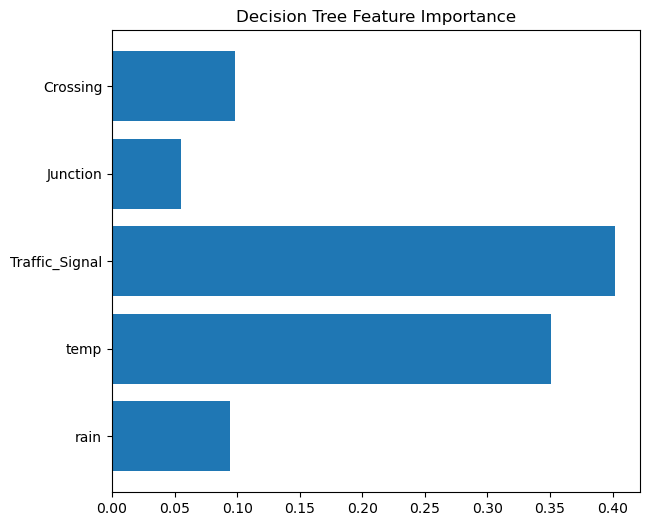

In [85]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(criterion = "entropy")
dt_clf = dt_clf.fit(X_train, y_train)

dt_pred = dt_clf.predict(X_test)

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators = 100)
rf_clf = rf_clf.fit(X_train, y_train)

rf_pred = rf_clf.predict(X_test)

print("Accuracy of Decision Tree Model:", accuracy_score(y_test, dt_pred))
print("Accuracy of Random Forest Model:", accuracy_score(y_test, rf_pred))

import matplotlib.pyplot as plt

plt.figure(figsize = (15, 6))
plt.subplot(1,2,1)
plt.barh(X.columns, dt_clf.feature_importances_)
plt.title("Decision Tree Feature Importance")

Based on the statistics and p values we calculated in task one, we will use the most signigicant variables according to p values to attempt to predict the severity of future accidents.

c.(20 points) Baseline model -- Linear Regression. Start with a simple linear regression model, fit different degrees (1, 2, 3, 5). 

Compare their performance using $R^2$ and RMSE; if converted to classification, report accuracy, precision and recall. 

Justify which model degree provides the best trade-off between performance and computational cost. Plot predited vs actual values to visualize model performance.

d.(20 points) Additional Models exploration. Each team should train a number of models corresponding to its size: 2 models for 1–2 members, 3 models for 3 members, and 4 models for 4–5 members.

Clearly label each memebers' name and report their model performance seperately.

e.(10 points) summarize all results in a comparison table, and identify the best-performing model and explain why.